1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

2: Load Dataset

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


3: Explore Dataset

In [3]:
print(df.shape)

df.info()

df.describe()

print(df.isnull().sum())

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


4: Rename Columns

In [4]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df.head()

,customerid,gender,age,annual_income_(k$),spending_score_(1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


5: Encode Gender

In [5]:
df["gender"] = df["gender"].map({
    "Male":0,
    "Female":1
})

6: Feature Selection

In [6]:
X = df[[
    "age",
    "annual_income_(k$)",
    "spending_score_(1-100)"
]]

7: Standardize Data

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

8: Elbow Method

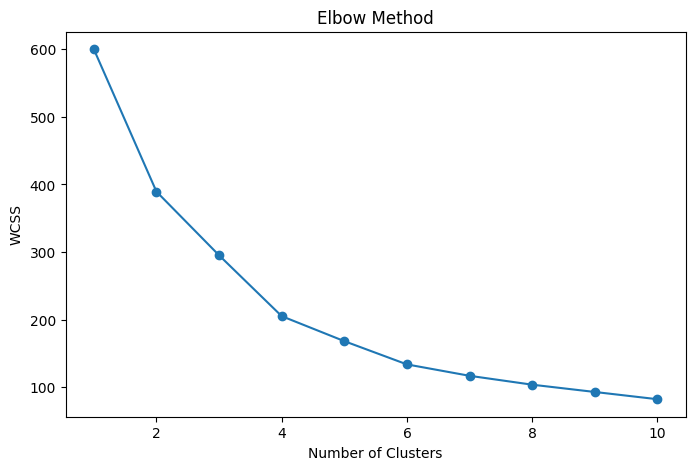

In [8]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

9: Apply K-Means

In [9]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

10: PCA

In [10]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

df["PCA1"] = pca_data[:,0]

df["PCA2"] = pca_data[:,1]

11: Visualize Clusters

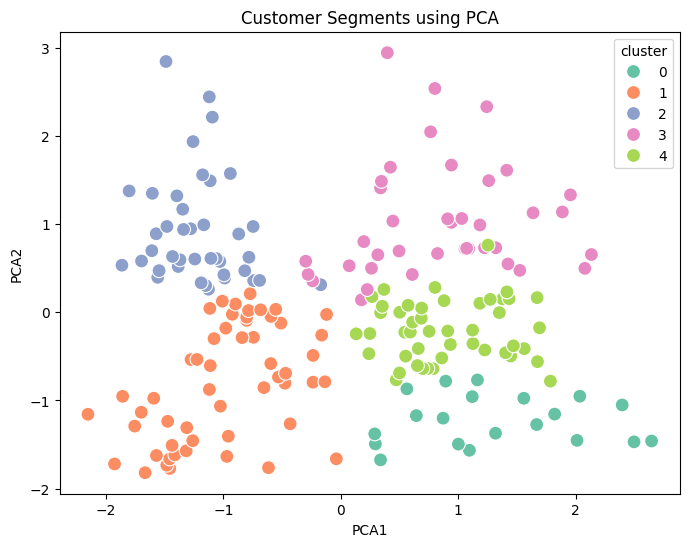

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="cluster",
    palette="Set2",
    s=100
)

plt.title("Customer Segments using PCA")

plt.show()

12: Cluster Characteristics

In [12]:
cluster_summary = df.groupby("cluster")[[
    "age",
    "annual_income_(k$)",
    "spending_score_(1-100)"
]].mean()

cluster_summary

,age,annual_income_(k$),spending_score_(1-100)
cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


13: Cluster Sizes

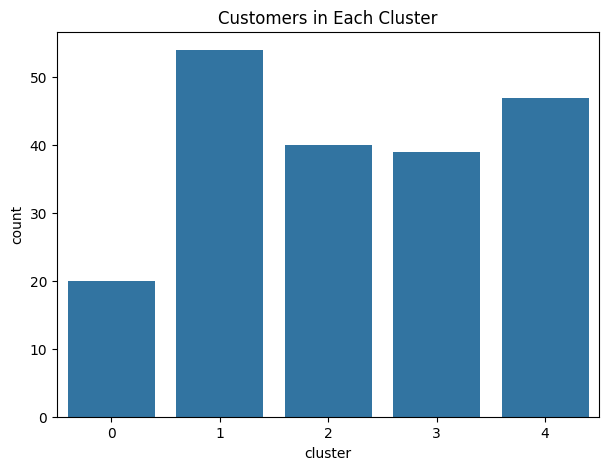

In [13]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="cluster",
    data=df
)

plt.title("Customers in Each Cluster")

plt.show()

14: Income vs Spending

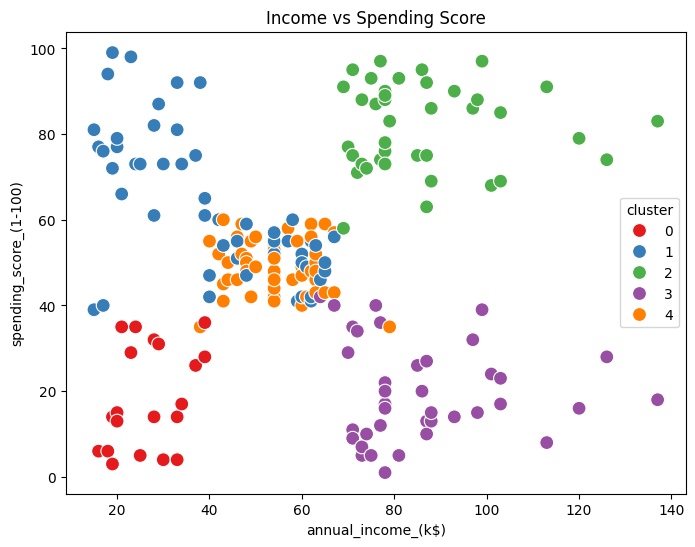

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="annual_income_(k$)",
    y="spending_score_(1-100)",
    hue="cluster",
    palette="Set1",
    s=100
)

plt.title("Income vs Spending Score")

plt.show()

15: Age vs Spending

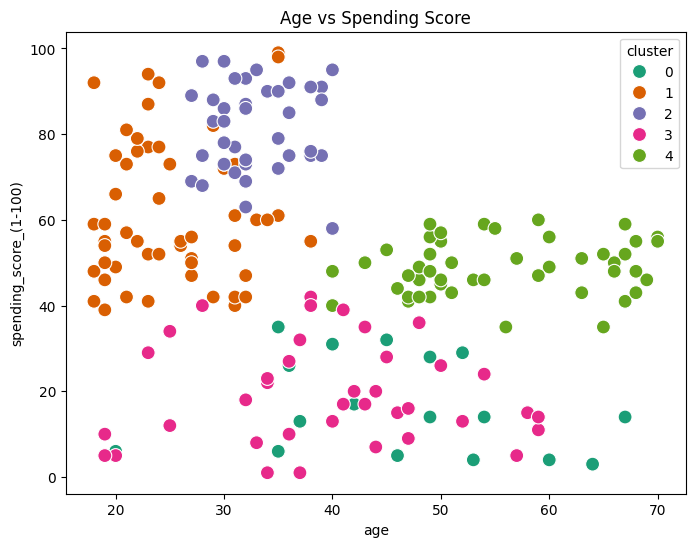

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="age",
    y="spending_score_(1-100)",
    hue="cluster",
    palette="Dark2",
    s=100
)

plt.title("Age vs Spending Score")

plt.show()

16: Print Cluster Means

In [16]:
print(cluster_summary)

               age  annual_income_(k$)  spending_score_(1-100)
cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064


17: Save Clustered Dataset

In [17]:
df.to_csv(
    "Mall_Customers_Clustered.csv",
    index=False
)

print("Clustered dataset saved.")

Clustered dataset saved.
